In [27]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from uncertainties import ufloat


In [16]:
df = pd.read_excel("data/rad_cassy.xlsx", sheet_name="kaliumcarbonat")
df0 = pd.read_excel("data/rad_cassy.xlsx", sheet_name="Messung Untergrund 2")
df0.columns = ["channel", "N_A"]
df.columns = ["channel", "N_A"]

df = df.merge(df0, how="inner", on="channel", suffixes=["", "_0"])
df["N_A_corrected"] = df["N_A"] - df["N_A_0"]
df.head()

,channel,N_A,N_A_0,N_A_corrected
0,0,8,7,1
1,1,12,9,3
2,2,9,5,4
3,3,3,5,-2
4,4,3,1,2


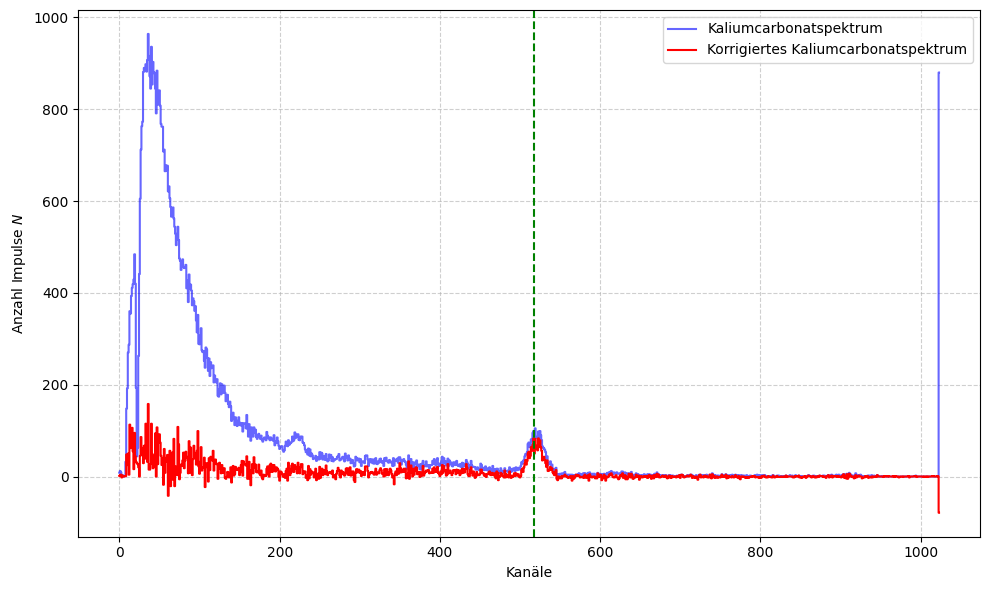

In [26]:
fig, ax = plt.subplots(figsize=(10, 6))

# 1. Originale Messung (Probe + Untergrund)
ax.step(df["channel"], df["N_A"], where='mid', 
        label="Kaliumcarbonatspektrum", color='blue', alpha=0.6)

# 2. Korrigierte Messung (Netto)
ax.step(df["channel"], df["N_A_corrected"], where='mid', 
        label="Korrigiertes Kaliumcarbonatspektrum", color='red', linewidth=1.5)

ax.axvline(x=518, color='green', linestyle='--', linewidth=1.5)


# Layout & Beschriftung
ax.set_xlabel("Kanäle")
ax.set_ylabel(r"Anzahl Impulse $N$")
ax.legend()
ax.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [28]:
def calculate_energy(channel_u, m_u = ufloat(2.8836, 0.0035), c_u = ufloat(-40.7, 1.8)):
    energy_u = m_u * channel_u + c_u
    return energy_u

peak_u = ufloat(518.0, 3.2) # Kanal +/- Unsicherheit

# 3. Berechnung
energie = calculate_energy(peak_u)

# 4. Ausgabe (mit den gewünschten 2 signifikanten Stellen in der Unsicherheit)
print(f"Energie: {energie:.2uP} keV")

Energie: 1453.0±9.6 keV


Bereich: Kanal 500 bis 548
Brutto-Impulse (N): 2507
Netto-Impulse (N_netto): 1669


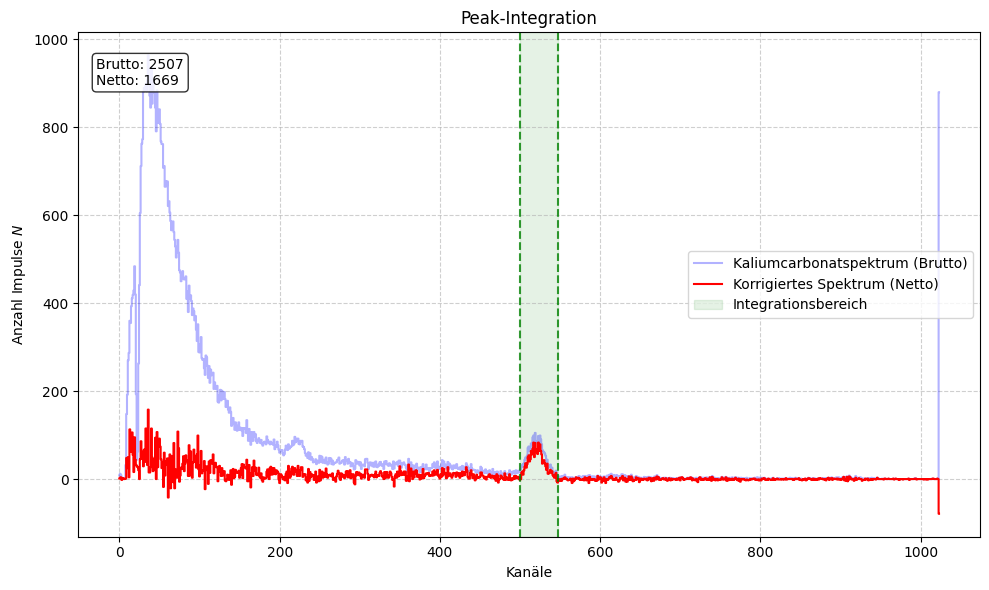

In [45]:
lower_limit = 500
upper_limit = 548

mask = (df["channel"] >= lower_limit) & (df["channel"] <= upper_limit)

brutto_sum = df.loc[mask, "N_A"].sum()
netto_sum = df.loc[mask, "N_A_corrected"].sum()

# Ergebnisse ausgeben
print(f"Bereich: Kanal {lower_limit} bis {upper_limit}")
print(f"Brutto-Impulse (N): {brutto_sum:.0f}")
print(f"Netto-Impulse (N_netto): {netto_sum:.0f}")

fig, ax = plt.subplots(figsize=(10, 6))

# Spektren zeichnen
ax.step(df["channel"], df["N_A"], where='mid', 
        label="Kaliumcarbonatspektrum (Brutto)", color='blue', alpha=0.3)
ax.step(df["channel"], df["N_A_corrected"], where='mid', 
        label="Korrigiertes Spektrum (Netto)", color='red', linewidth=1.5)

# Visualisierung der Grenzen
ax.axvline(x=lower_limit, color='green', linestyle='--', alpha=0.8)
ax.axvline(x=upper_limit, color='green', linestyle='--', alpha=0.8)
# Markiert den Bereich zwischen den Grenzen leicht grün
ax.axvspan(lower_limit, upper_limit, color='green', alpha=0.1, label="Integrationsbereich")

# Textfeld mit den Ergebnissen im Plot hinzufügen
info_text = f"Brutto: {brutto_sum:.0f}\nNetto: {netto_sum:.0f}"
ax.text(0.02, 0.95, info_text, transform=ax.transAxes, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

ax.set_xlabel("Kanäle")
ax.set_ylabel(r"Anzahl Impulse $N$")
ax.set_title("Peak-Integration")
ax.legend()
ax.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()